# Underfitting

In [101]:
import numpy as np
import pandas as pd
from sklearn import model_selection
from sklearn import linear_model
from sklearn import metrics
import matplotlib.pyplot as plt

In [102]:
N = 20
features = np.linspace(-10, 10, num=N)
target = 2 * features**2 - 3 + np.random.uniform(-2, 2, N)

,features,target
0,-10.000000,196.314634
1,-8.947368,158.205399
2,-7.894737,122.239706
3,-6.842105,89.845371
4,-5.789474,64.970896
5,-4.736842,40.761687
6,-3.684211,23.870087
7,-2.631579,8.904560
8,-1.578947,0.681327
9,-0.526316,-3.651486


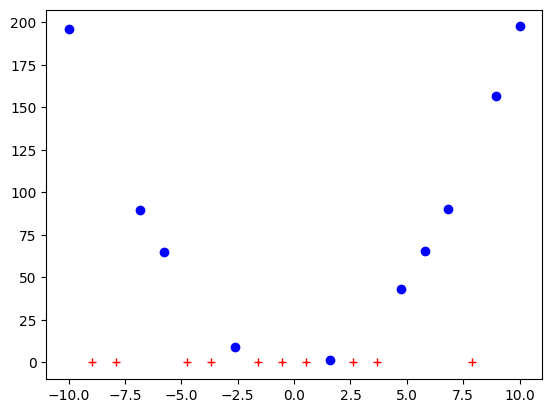

In [103]:
(train_features, test_features, train_target, test_target) = model_selection.train_test_split(features, target, test_size=N//2)
display(pd.DataFrame({'features': features, 'target': target}))
plt.plot(train_features, train_target, 'bo')
plt.plot(test_features, np.zeros_like(test_features), 'r+')

In [104]:
model = linear_model.LinearRegression()
model.fit(train_features.reshape(-1, 1), train_target)
predictions = model.predict(test_features.reshape(-1, 1))
print(sorted(predictions))

[np.float64(81.44628552846555), np.float64(82.47834395721625), np.float64(85.57451924346837), np.float64(86.60657767221907), np.float64(88.67069452972049), np.float64(89.7027529584712), np.float64(90.7348113872219), np.float64(92.7989282447233), np.float64(93.83098667347402), np.float64(97.95922038847684)]


In [105]:
# Korištenje np umjesto sklearn

In [106]:
model_one = np.poly1d(np.polyfit(train_features, train_target, 1))
predictions_one = model_one(test_features)
print(sorted(predictions_one))

[np.float64(81.44628552846554), np.float64(82.47834395721624), np.float64(85.57451924346837), np.float64(86.60657767221907), np.float64(88.67069452972049), np.float64(89.70275295847121), np.float64(90.73481138722191), np.float64(92.79892824472333), np.float64(93.83098667347404), np.float64(97.95922038847688)]


In [107]:
print(np.allclose(predictions, predictions_one))

True


In [108]:
print(np.sqrt(metrics.mean_squared_error(test_target, predictions_one)))

71.06548430909292


In [109]:
model_two = np.poly1d(np.polyfit(train_features, train_target, 2))
predictions_two = model_two(test_features)
print(sorted(predictions_two))

[np.float64(-2.607782964767273), np.float64(-2.5501882184687035), np.float64(1.7670338070193932), np.float64(10.862235828384161), np.float64(23.813901904848436), np.float64(24.21706512893845), np.float64(41.48595323089082), np.float64(121.09657631752938), np.float64(121.960497512008), np.float64(156.49827371591272)]


In [110]:
print(np.sqrt(metrics.mean_squared_error(test_target, predictions_two)))

0.9351426920927621


In [111]:
print(np.allclose(predictions, predictions_two))
print(np.sqrt(metrics.mean_squared_error(test_target, predictions_two)))

False
0.9351426920927621


In [112]:
model_three = np.poly1d(np.polyfit(train_features, train_target, 9))
predictions_three = model_three(test_features)
print(predictions_three)

[128.6825957   -2.26462049  40.45440045  21.36709639  24.38731434
  10.0540787  109.12854949   1.70970906 119.42217499  -1.8576367 ]


In [113]:
print(np.allclose(predictions, predictions_three))
print(np.sqrt(metrics.mean_squared_error(test_target, predictions_three)))

False
10.313056521765429


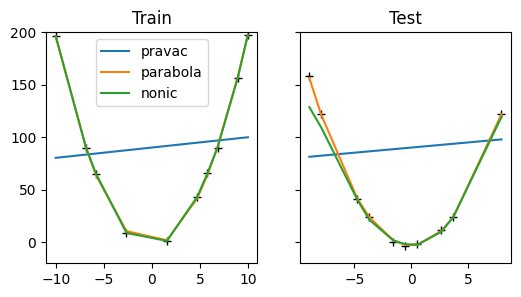

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
labels = ['pravac', 'parabola', 'nonic']
models = [model_one, model_two, model_three]
train = (train_features, train_target)
test = (test_features, test_target)
for ax, (ftr, tgt) in zip(axes, [train, test]):
  ax.plot(ftr, tgt, 'k+')
  for m, lbl in zip(models, labels):
    ftr = sorted(ftr)
    ax.plot(ftr, m(ftr), '-', label=lbl)
axes[1].set_ylim(-20, 200)
axes[0].set_title("Train")
axes[1].set_title("Test");
axes[0].legend(loc='upper center')

             Train Error  Test Error
Complexity                          
1           6.684281e+01   71.065484
2           1.012133e+00    0.935143
6           5.005900e-01    1.385992
9           1.314985e-13   10.313057


<Axes: xlabel='Complexity'>

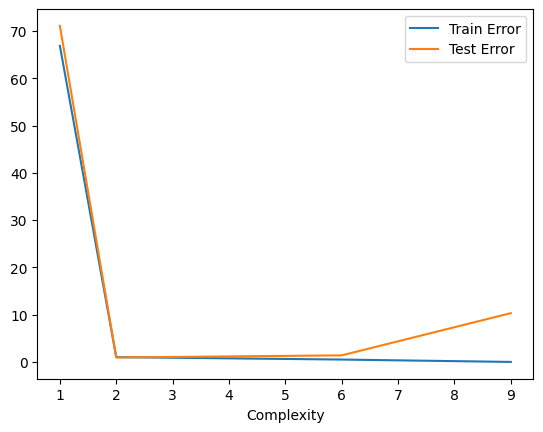

In [118]:
results = []
for complexity in [1, 2, 6, 9]:
  model = np.poly1d(np.polyfit(train_features, train_target, complexity))
  train_error = np.sqrt(metrics.mean_squared_error(train_target, model(train_features)))
  test_error = np.sqrt(metrics.mean_squared_error(test_target, model(test_features)))
  results.append((complexity, train_error, test_error))
columns = ["Complexity", "Train Error", "Test Error"]
results_df = pd.DataFrame.from_records(results,
columns=columns,
index="Complexity")
print(results_df)
results_df.plot()